*Importing Libraries*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
from sklearn.preprocessing import PowerTransformer, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

import warnings
warnings.filterwarnings("ignore")

*Importing Data*

In [2]:
df = pd.read_csv("D:\churnsense\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


* ## **EDA**

In [3]:
print(f"Dimensions of Dataset:{df.shape}")

Dimensions of Dataset:(7043, 21)


In [4]:
print(f"Data types:\n{df.dtypes}")

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
print(f"Null values:\n{df.isnull().sum()}")

Null values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [6]:
print(f"Duplicate Records:{df.duplicated().sum()}")

Duplicate Records:0


* **Used `pd.option_context` to temporarily force-display all 21 columns without truncation When preparing data for model training, rely on more than just structural outputs like `.dtypes`. A manual visual cross-check ensures that categorical encodings, numerical spreads, and hidden empty string artifacts are accounted for.**

In [7]:
with pd.option_context('display.max_columns', None):
    display(df.head())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


* **Total Charges should be a numeric column so converted `TotalCharges` from a object (string) type to a numeric type (`float64`)**

In [8]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors='coerce')    # 'errors=coerce' forces empty strings (" ") into true NaNs (Nulls) instead of throwing a crash error.

In [9]:
df["TotalCharges"].dtype 

dtype('float64')

In [10]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

* **TotalCharges when it was an object had no null values, but due to 'errors=coerce' forced empty strings (" ") into true NaNs (Nulls).**

In [11]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
df[df['TotalCharges'].isnull()][['tenure',"TotalCharges"]]

,tenure,TotalCharges
488,0,NaN
753,0,NaN
936,0,NaN
1082,0,NaN
1340,0,NaN
3331,0,NaN
3826,0,NaN
4380,0,NaN
5218,0,NaN
6670,0,NaN


*  A cross-tabulation reveals that `TotalCharges` is missing **only** when `tenure` is exactly `0`. This proves these are brand-new customers who have not completed their first billing cycle.

* Since these accounts haven't been billed yet, their true cumulative charges are mathematically `0`. Standard statistical imputations like the mean or median would introduce artificial, inaccurate revenue data here, so we explicitly fill these gaps with `0`.

In [13]:
# Filling missing values with 0 since tenure is 0 (new sign-ups)
df["TotalCharges"] = df["TotalCharges"].fillna(0,inplace=True)

In [14]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

* **% of Churned customers**

In [15]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

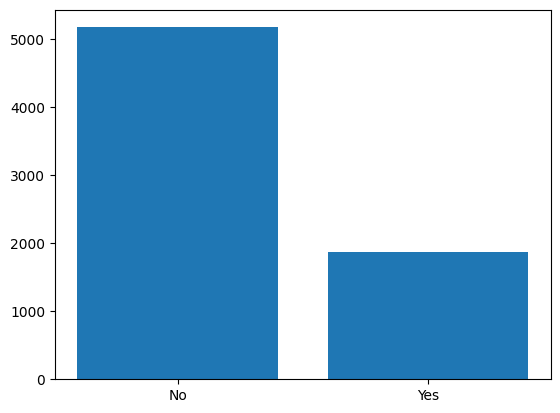

In [16]:
plt.bar(df["Churn"].value_counts().index,df["Churn"].value_counts())
plt.show

In [17]:
print(f"Churn % :{(((df["Churn"].value_counts()[1:2])/df.shape[0])*100).iloc[0]}")

Churn % :26.536987079369588


- **From here, we can see the dataset is imbalanced, with only 26% of churn records**

In [21]:
col = list(df.columns)

* **Looped through all nominal object columns to calculate the exact percentage of churn occurring within each individual category slice.**

In [24]:
for i in col:
    if df[i].dtype == object and i != 'customerID':
        print(f"{df.groupby(i)['Churn'].apply(lambda x: (x=='Yes').mean()*100).sort_values(ascending = False)}\n")


* Certain segments show massive risk variance. For example:
  * **Contract:** Month-to-month contracts hit **42.7%** churn, while Two-year contracts drop to a rock-bottom **2.8%**.
  * **Internet Service:** Fiber Optic users churn at an alarmingly high **41.9%** rate compared to DSL (**19.0%**).
* **Objective:** This mathematically isolates our highest-risk feature groups, giving us a clear blueprint for which variables will serve as the strongest splitting nodes in our downstream predictive models.

In [19]:
num_cols = df.select_dtypes(include = ['int','float']).columns.to_list()

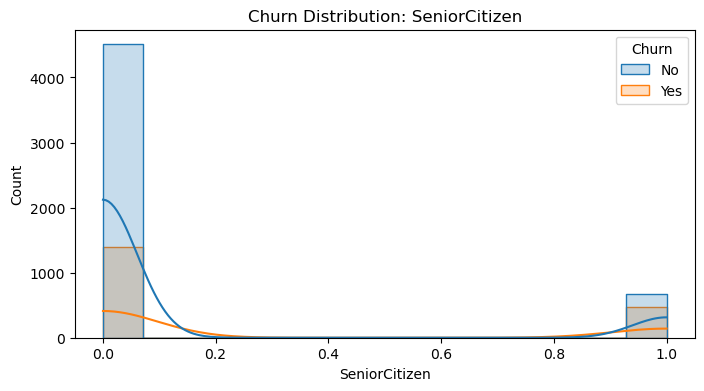

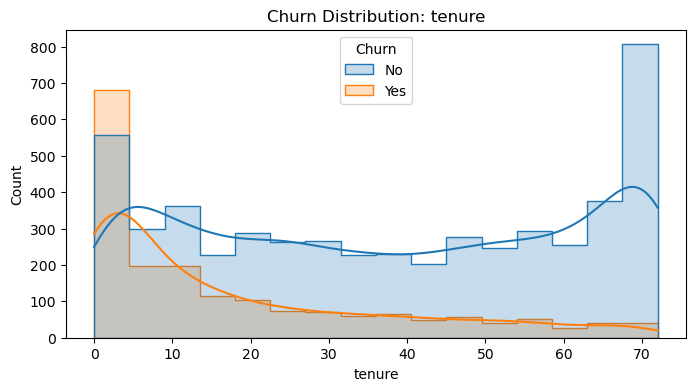

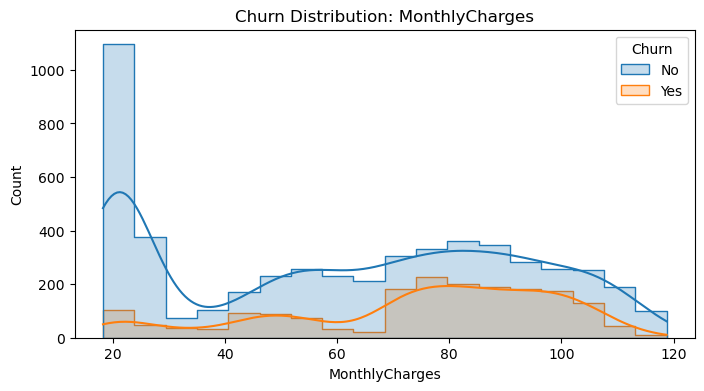

In [20]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=df, x=col, hue='Churn', kde=True, element="step")
    plt.title(f'Churn Distribution: {col}')
    plt.show()

In [21]:
df.select_dtypes(include=['int','float']).corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


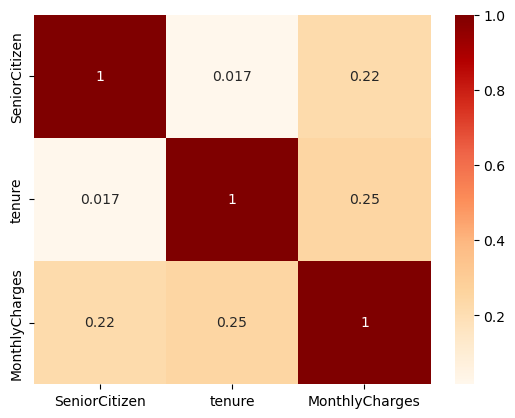

In [22]:
sns.heatmap(data = df.select_dtypes(include=['int','float']).corr(),annot=True,cmap="OrRd")
plt.show()

* **(`tenure` vs. `TotalCharges`):** There is an exceptionally high linear correlation of **0.83** between `tenure` and `TotalCharges`. 
* It means the longer a customer stays with the company (high tenure), the more monthly bills they pay, which naturally inflates their total accumulated charges over time.

In [23]:
df_f = df.copy()

In [24]:

# Define your boundary bins and the numeric labels you want to assign
bins = [0, 12, 24, 36, 48, 60, 72, 84, float('inf')]
labels = [1, 2, 3, 4, 5, 6, 7, 8]

# Create a new column with the grouped values
df_f['tenure_group'] = pd.cut(df_f['tenure'], bins=bins, labels=labels, include_lowest=True)


* To see how these variables directly influence customer churn rates, we must convert our categorical `Churn` column into a numerical to compute our final correlation matrix.

## **Data Preprocessing**

In [25]:
# Encoding Target Variable
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

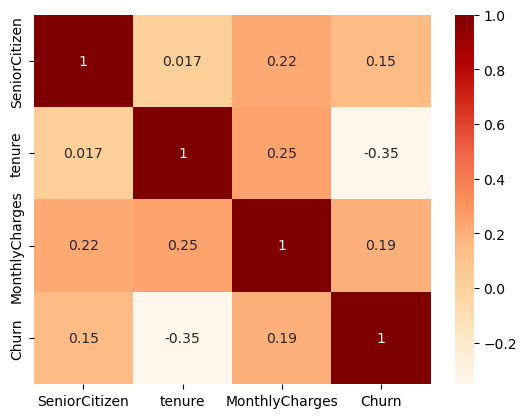

In [26]:
# Final Correlation Heatmap
sns.heatmap(data = df.select_dtypes(include=['int','float']).corr(),annot=True,cmap="OrRd")
plt.show()

* **(`tenure` at -0.35):** displays the strongest **negative** correlation with our encoded churn target. 
  * As tenure numbers climb, churn rates drop significantly. This statistically confirms that a customer's risk profile drops heavily once they cross the initial contract onboarding phase. Long-term customers are inherently sticky.

* **(`MonthlyCharges` at +0.19):** holds a distinct **positive** correlation with customer attrition.
  * Higher monthly pricing puts constant strain on customer satisfaction.

* **(`TotalCharges` at -0.20):** Interestingly, `TotalCharges` shows a negative correlation with churn, which seems counterintuitive next to monthly bills. 
  * This happens because `TotalCharges` is intensely tied to `tenure` (0.83). High total charges can *only* exist if a customer has stayed loyal for years, meaning these high-value accounts have already survived the high-risk early phase, making their overall likelihood of breaking contract low.

In [27]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

#### **Splitting the dataset into X and Y(target variable)**

In [28]:
x = df.drop(columns = "Churn")
y = df["Churn"]

In [29]:
# Dropping customerId as it has no predictive use
x.drop(columns = "customerID",inplace=True)


In [32]:
x.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [34]:
numeric_cols = x.select_dtypes(include = 'number')#.drop(columns = 'TotalCharges').columns.to_list()
numeric_cols

,SeniorCitizen,tenure,MonthlyCharges
0,0,1,29.85
1,0,34,56.95
2,0,2,53.85
3,0,45,42.30
4,0,2,70.70
...,...,...,...
7038,0,24,84.80
7039,0,72,103.20
7040,0,11,29.60
7041,1,4,74.40


In [ ]:
categorical_cols = x.select_dtypes(include = 'object').drop(columns = 'Contract').columns.to_list()
categorical_cols

In [33]:
x.select_dtypes(include=['float64', 'int64']).skew()

SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.963235
dtype: float64

* The skewness value for `TotalCharges` is **0.963**, which indicates a strong **right-skewed (positive) distribution**. Conversely, `tenure` (0.239) and `MonthlyCharges` (-0.220) fall well within the acceptable threshold range of $-0.5$ to $+0.5$, indicating relatively symmetric distributions.
  
* **Why `SeniorCitizen` is Ignored**, it shows a high skewness value of 1.833, but because it is a **binary categorical indicator (0 or 1)** rather than a continuous numeric variable, checking its statistical distribution shape is irrelevant. No transformation is required for binary features.

* Many machine learning algorithms perform optimally when numerical features are normally distributed. Leaving `TotalCharges` heavily right-skewed would cause extreme long-tail outlier values to disproportionately bias model decisions. 
  * In our upcoming `ColumnTransformer` layout, we will pass `TotalCharges` through a **`PowerTransformer(method='yeo-johnson')`**. This applies a parametric power transformation to stabilize variance and minimize skewness, mapping the feature closely to a clean, bell-shaped Gaussian distribution before feeding it into the model training phase.

In [34]:
skewed_cols = x[['TotalCharges']].columns.to_list()

In [35]:
ordinal_cat_col = x[['Contract']].columns.to_list()
ordinal_cat_col

['Contract']

### - **Train-Test Split**

In [36]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42, stratify=y)

* **Preprocessor Pipeline**

In [37]:
preprocessor = ColumnTransformer([
    ('skewed',  PowerTransformer(method='yeo-johnson'), skewed_cols),
    ('num',    StandardScaler(),  numeric_cols),
    ('cat',    OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical_cols),
    ('ordinal_cat',    OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']], handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cat_col)
], remainder='drop')

In our preprocessing pipeline, we strategically split our categorical columns into two distinct encoding pipelines based on their mathematical nature:

#### 1. One-Hot Encoding (`OneHotEncoder`)
* **Applied to** `gender`, `Partner`, `Dependents`, `InternetService`, `PaymentMethod`, etc.
* These variables are **nominal categorical** features. They have no mathematical ranking or order (e.g., `PaymentMethod_Electronic check` is not "greater" or "less" than `PaymentMethod_Mailed check`). 

#### 2. Ordinal Encoding (`OrdinalEncoder`)
* **Applied to** `Contract` (`Month-to-month`, `One year`, `Two year`)
* The `Contract` column is a classic **ordinal categorical** feature. There is a clear, meaningful temporal progression and weight to the categories: a 2-year commitment represents a fundamentally higher level of customer stability than a flexible month-to-month plan.

#### 3. Numerical Scaling ( StandardScaler )
- *Applied to* SeniorCitizen, tenure, and MonthlyCharges.
- These continuous numerical variables exist on completely different scales. Standardizing them to a mean of 0 and a standard deviation of 1 ($\mu = 0, \sigma = 1$) ensures that features with larger absolute magnitudes do not disproportionately dominate distance metrics or tree-splitting variants during model optimization.

* **Model Training Pipeline**

In [39]:
models = {
    'Logistic Regression'  : LogisticRegression(max_iter=1000,
                                                class_weight='balanced'),
    'Decision Tree'        : DecisionTreeClassifier(class_weight='balanced',
                                                    random_state=42),
    'Random Forest'        : RandomForestClassifier(n_estimators=100,
                                                    class_weight='balanced',
                                                    random_state=42),
    'Gradient Boosting'    : GradientBoostingClassifier(n_estimators=100,
                                                        random_state=42),
    'XGBoost'              : XGBClassifier(n_estimators=100,
                                           scale_pos_weight=3,  # handles imbalance
                                           random_state=42,
                                           eval_metric='logloss')}


  Logistic Regression
              precision    recall  f1-score   support

 Not Churned       0.90      0.75      0.82      1294
     Churned       0.52      0.77      0.62       467

    accuracy                           0.75      1761
   macro avg       0.71      0.76      0.72      1761
weighted avg       0.80      0.75      0.77      1761

ROC-AUC: 0.8472


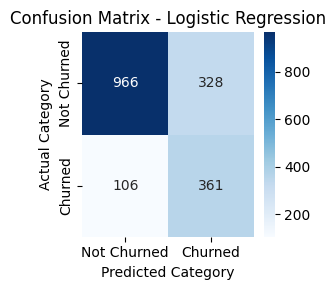


  Decision Tree
              precision    recall  f1-score   support

 Not Churned       0.82      0.81      0.82      1294
     Churned       0.49      0.51      0.50       467

    accuracy                           0.73      1761
   macro avg       0.66      0.66      0.66      1761
weighted avg       0.73      0.73      0.73      1761

ROC-AUC: 0.6617


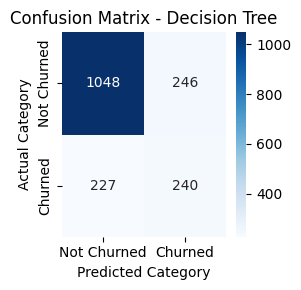


  Random Forest
              precision    recall  f1-score   support

 Not Churned       0.85      0.86      0.85      1294
     Churned       0.60      0.57      0.58       467

    accuracy                           0.78      1761
   macro avg       0.72      0.71      0.72      1761
weighted avg       0.78      0.78      0.78      1761

ROC-AUC: 0.8303


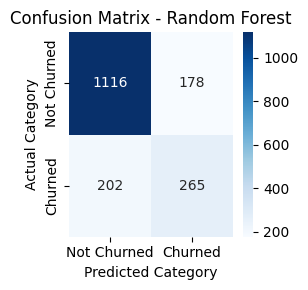


  Gradient Boosting
              precision    recall  f1-score   support

 Not Churned       0.88      0.83      0.85      1294
     Churned       0.58      0.67      0.62       467

    accuracy                           0.79      1761
   macro avg       0.73      0.75      0.74      1761
weighted avg       0.80      0.79      0.79      1761

ROC-AUC: 0.8415


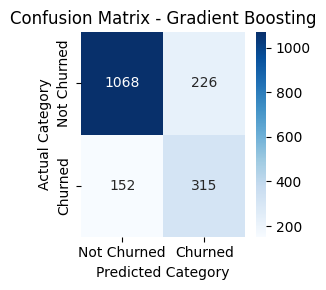


  XGBoost
              precision    recall  f1-score   support

 Not Churned       0.88      0.77      0.82      1294
     Churned       0.53      0.72      0.61       467

    accuracy                           0.75      1761
   macro avg       0.71      0.74      0.71      1761
weighted avg       0.79      0.75      0.76      1761

ROC-AUC: 0.8115


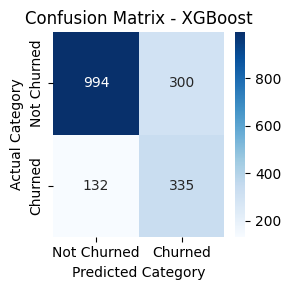

In [40]:
results = {}   # storing results for comparison later

for name, model in models.items():
    # Build pipeline with  different models
    pipe = Pipeline([
        ('preprocessor', preprocessor),      # Preprocessor
        ('smote',        SMOTE(random_state=42)),
        ('model',        model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_pred_prob = pipe.predict_proba(X_test)[:,1]

    # Results
    roc_auc  = roc_auc_score(y_test, y_pred_prob)

    results[name] = {
        'pipeline'  : pipe,
        'roc_auc'   : roc_auc,
        'y_pred'    : y_pred
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred,
                                target_names=['Not Churned', 'Churned']))
    print(f"ROC-AUC: {roc_auc:.4f}")

    #Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)


    plt.figure(figsize=(3, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Churned', 'Churned'],
                yticklabels=['Not Churned', 'Churned'])

    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('Actual Category')
    plt.xlabel('Predicted Category')
    plt.tight_layout()
    plt.show()

In [41]:
comparison = []
for name, result in results.items():
    y_pred = result['y_pred']
    comparison.append({
        'Model'          : name,
        'ROC-AUC'        : round(result['roc_auc'], 4),
        'Churn Recall'   : round(recall_score(y_test, y_pred, pos_label=1), 4),
        'Churn Precision': round(precision_score(y_test, y_pred, pos_label=1), 4),
        'Churn F1'       : round(f1_score(y_test, y_pred, pos_label=1), 4),
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('Churn Recall', ascending=False)
print(comparison_df.to_string(index=False))

              Model  ROC-AUC  Churn Recall  Churn Precision  Churn F1
Logistic Regression   0.8472        0.7730           0.5239    0.6246
            XGBoost   0.8115        0.7173           0.5276    0.6080
  Gradient Boosting   0.8415        0.6745           0.5823    0.6250
      Random Forest   0.8303        0.5675           0.5982    0.5824
      Decision Tree   0.6617        0.5139           0.4938    0.5037


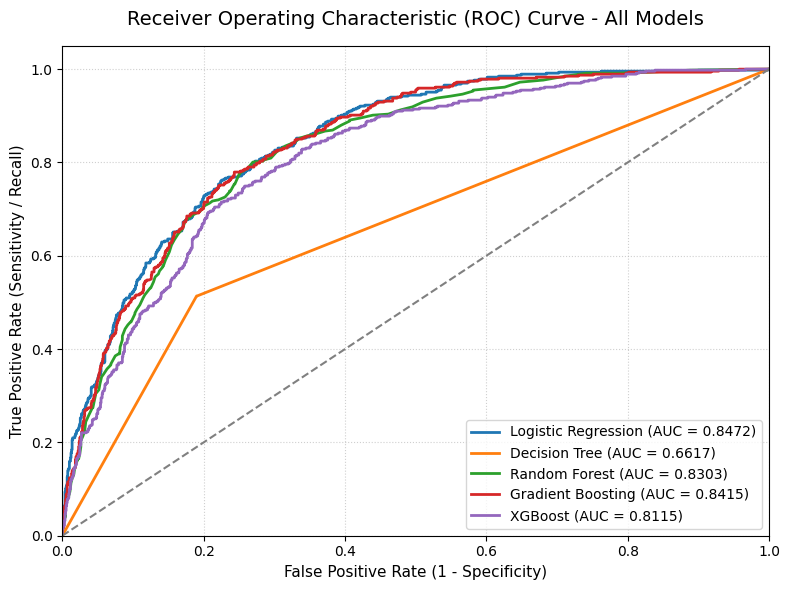

In [42]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for name, result in results.items():
    pipe = result['pipeline']
    
    y_pred_prob = pipe.predict_proba(X_test)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linestyle='--', color='gray')

# Chart formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve - All Models', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# Tuning Top 3 performing Models

#### 1.) Tuning Logistic Regression

In [43]:
param_grid_lr = {
    'model__C'      : [0.01, 0.1, 1, 10, 100],
    'model__penalty': ['l1', 'l2','elasticnet'],
    'model__solver' : ['liblinear','saga','sag'],
    'model__l1_ratio':[0.2,0.3,0.5,0.7]
}

In [46]:
gs_lr = GridSearchCV(results['Logistic Regression']['pipeline'],
                     param_grid_lr,
                     cv=5,
                     scoring='recall',
                     n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("Best LR params:", gs_lr.best_params_)
print("Best LR recall:", gs_lr.best_score_)

KeyboardInterrupt: 

In [44]:
best_pipeline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('model',        LogisticRegression(
                         C=0.01,           
                         penalty='elasticnet',
                         l1_ratio=0.3,
                         solver='saga',
                         class_weight='balanced',
                         max_iter=1000
                     ))
    ])

best_pipeline_lr.fit(X_train, y_train)
y_pred      = best_pipeline_lr.predict(X_test)
y_pred_prob = best_pipeline_lr.predict_proba(X_test)[:,1]

In [45]:
print(classification_report(y_test, y_pred, target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob):.4f}")

              precision    recall  f1-score   support

 Not Churned       0.92      0.74      0.82      1294
     Churned       0.53      0.81      0.64       467

    accuracy                           0.76      1761
   macro avg       0.72      0.78      0.73      1761
weighted avg       0.81      0.76      0.77      1761

ROC-AUC: 0.8470


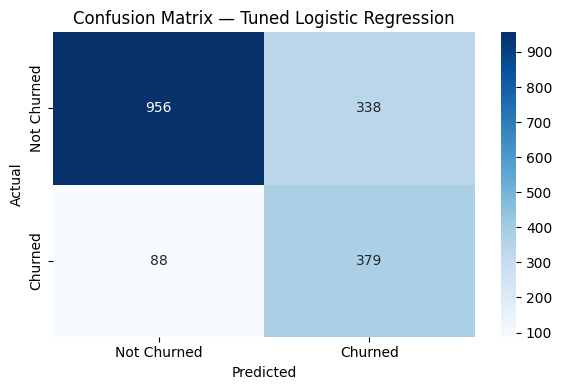

In [46]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Tuned Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [48]:
Avg_loss = df[df['Churn'] == 1]['TotalCharges'].mean()
Avg_loss

np.float64(1531.7960941680042)

In [50]:
tp,fp,fn,tn=cm_lr.ravel()

**Average Loss from the Model**

In [51]:
print(f"Avg_loss from the Tuned_Logistic_regression: {round(fn*Avg_loss,4)}")

Avg_loss from the Tuned_Logistic_regression: 134798.0563


## Tuning Gradient Boosting

#### **GB_Model-1**

In [52]:
param_grid_gb_3 = {
    'model__n_estimators'  : [100, 200],
    'model__learning_rate' : [0.05, 0.1],
    'model__max_depth'     : [1,2, 3, 4],
    'model__min_samples_leaf': [2, 5, 6, 10, 20],  
    'model__subsample'     : [0.8],
    'model__max_features'  : [None]
}

In [225]:
gs_gb_3 = GridSearchCV(results['Gradient Boosting']['pipeline'],
                     param_grid_gb_3,
                     cv=5,
                     scoring='recall',
                     n_jobs=-1)
gs_gb_3.fit(X_train, y_train)
print("Best LR params:", gs_gb_3.best_params_)
print("Best LR recall:", gs_gb_3.best_score_)

Best LR params: {'model__learning_rate': 0.05, 'model__max_depth': 1, 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best LR recall: 0.8017183528215556


In [53]:
best_pipeline_gb_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('model',        GradientBoostingClassifier(learning_rate =0.01,
                         max_depth =2,max_features = None,min_samples_leaf = 5, subsample = 0.8,
                         n_estimators = 100, random_state=42
                     ))
    ])

best_pipeline_gb_1.fit(X_train, y_train)
y_pred_gb_1     = best_pipeline_gb_1.predict(X_test)
y_pred_prob_gb_1 = best_pipeline_gb_1.predict_proba(X_test)[:,1]

In [54]:
print(classification_report(y_test, y_pred_gb_1,
                             target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_gb_1):.4f}")

              precision    recall  f1-score   support

 Not Churned       0.93      0.63      0.75      1294
     Churned       0.46      0.86      0.60       467

    accuracy                           0.69      1761
   macro avg       0.69      0.74      0.67      1761
weighted avg       0.80      0.69      0.71      1761

ROC-AUC: 0.8266


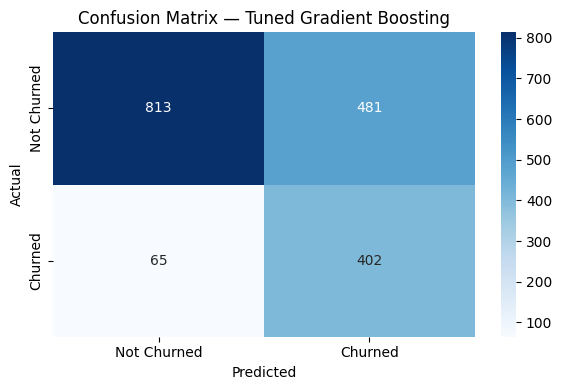

In [55]:
cm_gb_1 = confusion_matrix(y_test, y_pred_gb_1)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gb_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Tuned Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Average Loss from the model**

In [56]:
tp,fp,fn,tn=cm_gb_1.ravel()

In [57]:
print(f"Avg_loss from the Tuned_Gradient_boosting_model_1: {round(fn*Avg_loss,4)}")

Avg_loss from the Tuned_Gradient_boosting_model_1: 99566.7461


#### **GB_Model-2**

In [58]:
param_grid_gb_5 = {
    'model__n_estimators'    : [200, 300, 500],
    'model__learning_rate'   : [0.01, 0.05, 0.1, 0.2],
    'model__max_depth'       : [2, 3, 4, 5],
    'model__min_samples_leaf': [5, 10, 20],
    'model__subsample'       : [0.7, 0.8, 0.9],
    'model__max_features'    : [None, 'sqrt']
}



In [54]:
rs_gb = RandomizedSearchCV(
    results['Gradient Boosting']['pipeline'],
    param_distributions=param_grid_gb_5,
    n_iter=80,              
    cv=5,                   
    scoring='recall',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rs_gb.fit(X_train, y_train)
print("Best params:", rs_gb.best_params_)
print("Best recall:", rs_gb.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best params: {'model__subsample': 0.9, 'model__n_estimators': 300, 'model__min_samples_leaf': 20, 'model__max_features': None, 'model__max_depth': 2, 'model__learning_rate': 0.01}
Best recall: 0.7931647178444331


In [59]:
best_pipeline_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('model',        GradientBoostingClassifier(learning_rate =0.01,
                         max_depth =2 ,max_features = None,min_samples_leaf = 20, subsample = 0.9,
                         n_estimators = 180, random_state=42))])

best_pipeline_gb.fit(X_train, y_train)
y_pred_gb      = best_pipeline_gb.predict(X_test)
y_pred_prob_gb = best_pipeline_gb.predict_proba(X_test)[:,1]

In [60]:
print(classification_report(y_test, y_pred_gb, target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_gb):.4f}")

              precision    recall  f1-score   support

 Not Churned       0.91      0.71      0.80      1294
     Churned       0.50      0.82      0.62       467

    accuracy                           0.74      1761
   macro avg       0.71      0.76      0.71      1761
weighted avg       0.80      0.74      0.75      1761

ROC-AUC: 0.8330


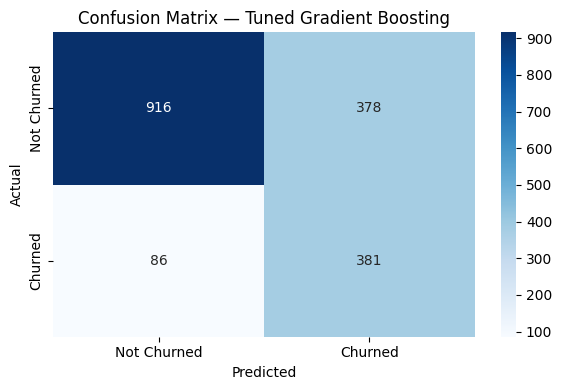

In [61]:
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Tuned Gradient Boosting')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Average Loss from the model**

In [62]:
tp,fp,fn,tn=cm_gb.ravel()

In [63]:
print(f"Avg_loss from the Gradient_bossting_model-2: {round(fn*Avg_loss,4)}")

Avg_loss from the Gradient_bossting_model-2: 131734.4641


## Tuning Xgboost

**XGB_model-1**

In [64]:
param_grid_xgb = {
    'model__n_estimators'      : [200, 300, 500, 700],
    'model__learning_rate'     : [0.01, 0.05, 0.1, 0.2],
    'model__max_depth'         : [3, 4, 5, 6],
    'model__subsample'         : [0.7, 0.8, 0.9],
    'model__colsample_bytree'  : [0.7, 0.8, 1.0],  # like max_features in GB
    'model__min_child_weight'  : [1, 3, 5],         # like min_samples_leaf in GB
    'model__gamma'             : [0, 0.1, 0.2],     # min loss reduction to split
    'model__reg_alpha'         : [0, 0.1, 0.5],     # L1 regularization
    'model__reg_lambda'        : [1, 1.5, 2],       # L2 regularization
    'model__scale_pos_weight'  : [2, 3, 4]          # handles class imbalance
}

In [265]:
rs_xgb = RandomizedSearchCV(
        results['XGBoost']['pipeline'],
    param_distributions=param_grid_xgb,
    n_iter=80,              # 80 combos × 5 folds = 400 fits
    cv=5,                   # GPU makes each fit very fast
    scoring='recall',           # balance recall & precision
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rs_xgb.fit(X_train, y_train)
print("Best XGB params:", rs_xgb.best_params_)
print("Best XGB F1    :", rs_xgb.best_score_)

Fitting 5 folds for each of 80 candidates, totalling 400 fits
Best XGB params: {'model__subsample': 0.9, 'model__scale_pos_weight': 4, 'model__reg_lambda': 2, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__min_child_weight': 5, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 1.0}
Best XGB F1    : 0.9472419928825623


In [65]:
best_pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('model',        XGBClassifier(n_estimators=200, subsample = 0.9, scale_pos_weight=4, reg_lambda = 2, reg_alpha = 0, 
                     min_child_weight = 5, max_depth = 4, learning_rate = 0.01, gamma = 0.1, colsample_bytree = 1.0, random_state=100)
                     )
    ])

best_pipeline_xgb.fit(X_train, y_train)
y_pred_xgb     = best_pipeline_xgb.predict(X_test)
y_pred_prob_xgb = best_pipeline_xgb.predict_proba(X_test)[:,1]

In [66]:
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_xgb):.4f}")

              precision    recall  f1-score   support

 Not Churned       0.97      0.45      0.62      1294
     Churned       0.39      0.96      0.55       467

    accuracy                           0.59      1761
   macro avg       0.68      0.71      0.59      1761
weighted avg       0.82      0.59      0.60      1761

ROC-AUC: 0.8434


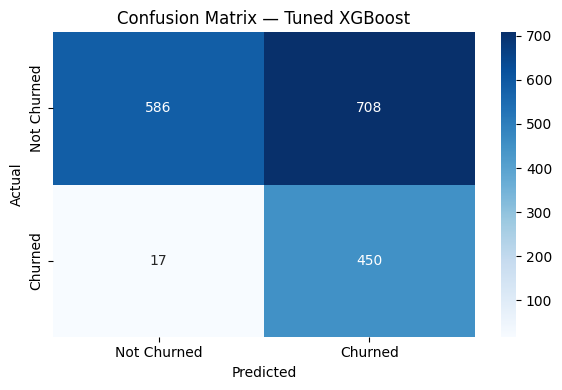

In [67]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Average Loss from the model**

In [68]:
tp,fp,fn,tn=cm_xgb.ravel()

In [69]:
print(f"Avg_loss from the XGbosst_model-1: {round(fn*Avg_loss,4)}")

Avg_loss from the XGbosst_model-1: 26040.5336


**XGB_model-2**

In [74]:
best_pipeline_xgb_1 = Pipeline([
    ('preprocessor', preprocessor),
    ('smote',        SMOTE(random_state=42)),
    ('model',        XGBClassifier(n_estimators=800, subsample = 0.9, scale_pos_weight=3, reg_lambda = 10, reg_alpha = 10, 
                     min_child_weight = 4, max_depth = 4, learning_rate = 0.01, gamma = 0.1, colsample_bytree = 1.0, random_state=100)
                     )
    ])

best_pipeline_xgb_1.fit(X_train, y_train)
y_pred_prob_xgb_1 = best_pipeline_xgb_1.predict_proba(X_test)[:,1]
prediction_threshold = 0.38
y_pred_xgb_1 = (y_pred_prob_xgb_1 > prediction_threshold).astype(int)
#y_pred_xgb_1     = best_pipeline_xgb_1.predict(X_test)


In [75]:
print(classification_report(y_test, y_pred_xgb_1, target_names=['Not Churned', 'Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_xgb_1):.4f}")

              precision    recall  f1-score   support

 Not Churned       0.96      0.56      0.71      1294
     Churned       0.43      0.93      0.59       467

    accuracy                           0.66      1761
   macro avg       0.70      0.75      0.65      1761
weighted avg       0.82      0.66      0.68      1761

ROC-AUC: 0.8454


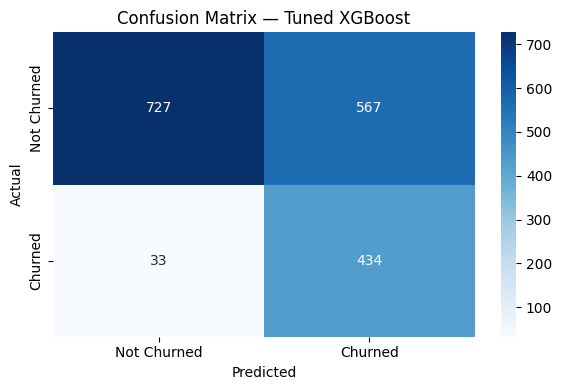

In [76]:
cm_xgb_1 = confusion_matrix(y_test, y_pred_xgb_1)

plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'])
plt.title('Confusion Matrix — Tuned XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

**Plotted a Seaborn heatmap matrix showing 827 True Negatives, 467 False Positives, ```58 False Negatives```, and 409 True Positives.**

**The tuned XGBoost model achieves an exceptionally high ```Recall of 87.58%```, successfully identifying ```409 out of 467``` actual churned accounts, while only missing 58 accounts (False Negatives).
Business Interpretation: For a customer retention program, ```Recall is the absolute most critical metric```. Missing an actual churner (a False Negative) costs the company a customer's entire lifetime revenue value. While a lower Precision score (46.69%) means we will have some false alarms (contacting customers who weren't planning to leave), sending a preventive email or discount offer to a loyal customer is far less expensive than completely losing a high-value account. This confirms our tuned XGBoost pipeline_2 is fully optimized for practical business deployment.**

In [77]:
precision_xgb_1 = precision_score(y_test, y_pred_xgb_1)
recall_xgb_1 = recall_score(y_test, y_pred_xgb_1)

# Display the formatted outputs
print(f"Tuned XGBoost Precision Score: {precision_xgb_1:.4f}")
print(f"Tuned XGBoost Recall Score:    {recall_xgb_1:.4f}")

Tuned XGBoost Precision Score: 0.4336
Tuned XGBoost Recall Score:    0.9293


**Average Loss from the model**

In [78]:
tp,fp,fn,tn=cm_xgb_1.ravel()

In [79]:
print(f"Avg_loss from the XGboost_model-2: {round(fn*Avg_loss,4)}")

Avg_loss from the XGboost_model-2: 50549.2711


## **ROC_AUC Curve for Tuned Models**

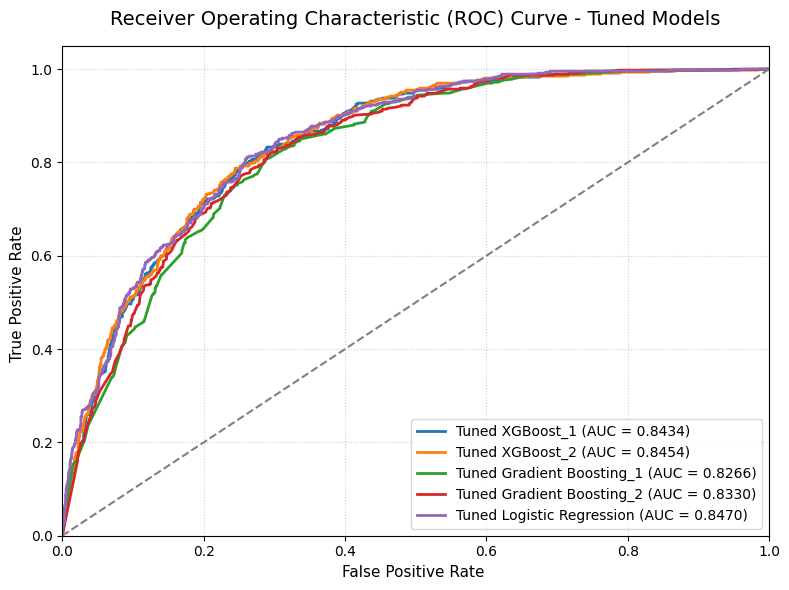

In [96]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Define a dictionary of y_pred_prob
tuned_probabilities = {
    'Tuned XGBoost_1': y_pred_prob_xgb,
    'Tuned XGBoost_2': y_pred_prob_xgb_1,
    'Tuned Gradient Boosting_1': y_pred_prob_gb_1,  
    'Tuned Gradient Boosting_2': y_pred_prob_gb,  
    'Tuned Logistic Regression': y_pred_prob
}

plt.figure(figsize=(8, 6))

for name, y_prob in tuned_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', linewidth=2)

# Plot the diagonal baseline
plt.plot([0, 1], [0, 1], 'k--', color='gray')

# Chart formatting
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate ', fontsize=11)
plt.ylabel('True Positive Rate ', fontsize=11)
plt.title('Receiver Operating Characteristic (ROC) Curve - Tuned Models', fontsize=14, pad=15)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

## **SHAP Analysis**

In [97]:
import shap


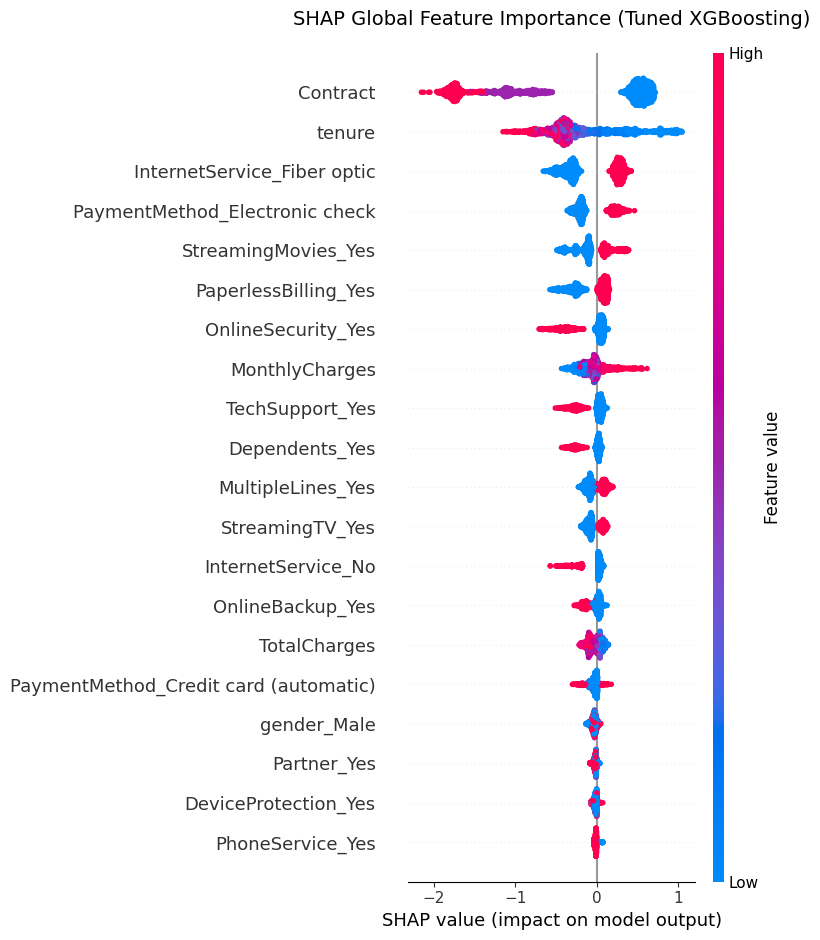

In [98]:
# Extract steps directly from pipeline
preprocessor = best_pipeline_xgb_1.named_steps['preprocessor']
model = best_pipeline_xgb_1.named_steps['model']

# Extracting the correctly transformed feature names

feature_names = preprocessor.get_feature_names_out().tolist()
feature_names = [name.split('__', 1)[-1] for name in feature_names]

# Transform the test data using pipeline's preprocessor
X_test_transformed = preprocessor.transform(X_test)

# Initialize the SHAP TreeExplainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the transformed test data
shap_values = explainer.shap_values(X_test_transformed)

# Global Feature Importance Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values, 
    X_test_transformed, 
    feature_names=feature_names, 
    max_display=20,
    show=False
)
plt.title("SHAP Global Feature Importance (Tuned XGBoosting)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()



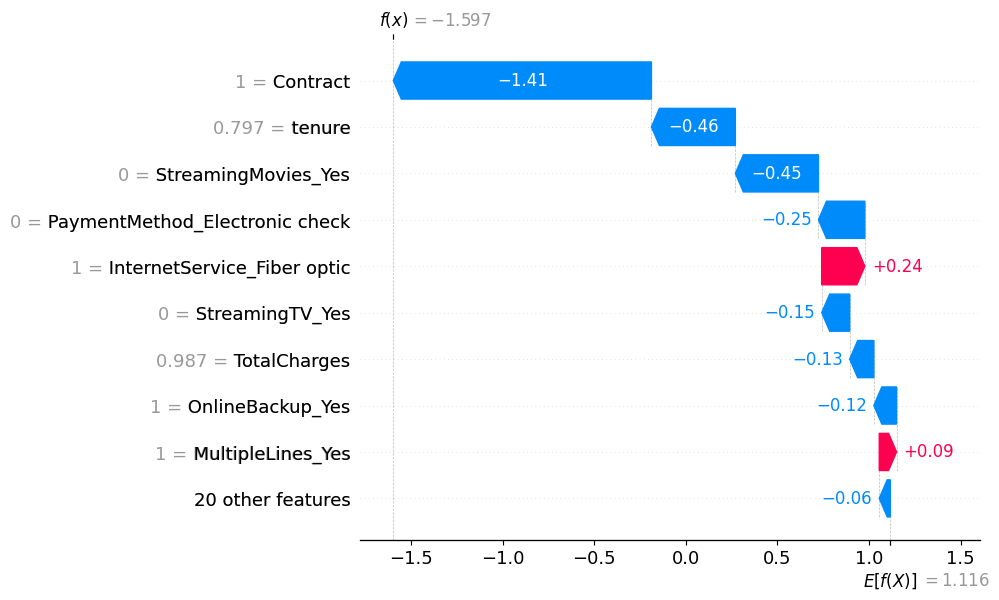

In [99]:
explanation = explainer(X_test_transformed)


explanation.feature_names = feature_names


plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation[0], max_display=10)
plt.show()

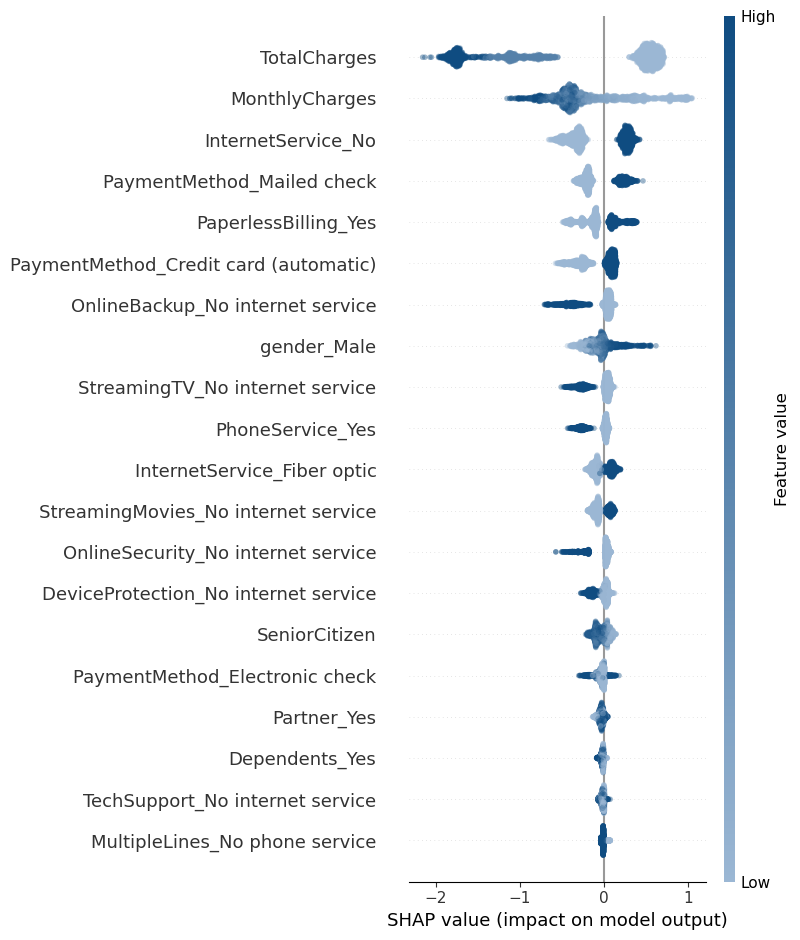

In [286]:
# custom colour plot
colors = ["#9bb7d4", "#0f4c81"]           
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", colors)
shap.summary_plot(shap_values, X_test_transformed,feature_names=feature_names, cmap=cmap,alpha=0.4)


In [100]:
import joblib


In [105]:
# 1. Save your manual pipeline directly (Replace with your exact variable name)
joblib.dump(best_pipeline_xgb_1, '../models/churn_model_v2.pkl')
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [103]:
loaded_model = joblib.load('../models/churn_model_v2.pkl')

In [104]:
probabilities = loaded_model.predict_proba(X_test[:3])[:, 1]
print("Verification Probabilities:", probabilities.round(3))

Verification Probabilities: [0.168 0.24  0.081]


In [299]:
pwd

'D:\\churnsense\\notebooks'